To make the plots in this tutorial interactive, you will need to have `ipympl` [installed in your environment](https://matplotlib.org/ipympl/installing.html). Once this is installed, run the following cell:

In [2]:
# NBVAL_SKIP
# Run this cell to make the plots interactive!
%matplotlib widget 

# Analysing iMD forces from NanoVer recordings

The aim of this notebook is to demonstrate how the iMD data from NanoVer recordings of simulations can be analysed in Jupyter. We will use a pre-prepared recording of an OpenMM simulation of a methane + nanotube system. If you're looking for a challenge, check out our [OpenMM polyalanine simulation notebook](../openmm/openmm_polyalanine.ipynb) first to learn how to record your own iMD-VR simulation to analyse!

We will examine a pre-prepared trajectory produced during a simulation of the methane + nanotube system, in which a user interacts with the carbon atom of the methane to pull the methane around in space, through the nanotube in one direction, and then back through the nanotube in the other direction. When running this simulation, the forces and velocities of the atoms in the system were explicitly included in the data output from the simulation.

## Examine the system and recording (optional)

The methane + nanotube system is included in our example systems, along with a recording of a short NanoVer iMD-XR session with it. We can host them in NanoVer in the usual way and take a brief look in the headset to see what we're working with. If you like, you can also use this setup to create your own recording to use in the rest of the notebook.

In [3]:
from nanover.app import OmniRunner
from nanover.openmm import OpenMMSimulation
from nanover.recording import PlaybackSimulation

nanotube_simulation = OpenMMSimulation.from_bundle_path("../systems/openmm/nanotube.openmm.zip")
# including system forces and velocities is optional
nanotube_simulation.include_forces = True
nanotube_simulation.include_velocities = True

nanotube_recording = PlaybackSimulation.from_path(path="../systems/recordings/nanotube-recording.nanover.zip")
imd_runner = OmniRunner.with_basic_server(nanotube_simulation, nanotube_recording, name='nanotube examples')

In [4]:
from nanover.jupyter import NanoverJupyterUtilities

utilities = NanoverJupyterUtilities.from_runner(imd_runner)
utilities.show_controls()
utilities.use_recording_commands()

Button(description='Close Server', style=ButtonStyle())

interactive(children=(Dropdown(description='Force Type', index=1, options=(('Gaussian', 'gaussian'), ('Harmoni…

interactive(children=(IntSlider(value=100, description='Force Scale', max=1000, min=1), Output()), _dom_classe…

interactive(children=(FloatSlider(value=0.4, description='Force Range', max=2.0, min=0.1, step=0.05), Output()…

interactive(children=(FloatSlider(value=1.0, description='Passthrough', max=1.0), Output()), _dom_classes=('wi…

## Extracting trajectories from the recording

As in the [earlier notebook](session_recording_for_mdanalysis.ipynb) we use a utility function to extract each trajectory from the recording. A NanoVer session recording can contain multiple trajectories, and we'll just take the first one:

In [5]:
from nanover.recording import trajectories_from_recording

trajectories = trajectories_from_recording("../systems/recordings/nanotube-recording.nanover.zip")
trajectories

[<NanoverTrajectory ../systems/recordings/nanotube-recording.nanover.zip[1:2627] with 1468 frames of 65 atoms>]

In [6]:
trajectory = trajectories[0]
trajectory

<NanoverTrajectory ../systems/recordings/nanotube-recording.nanover.zip[1:2627] with 1468 frames of 65 atoms>

## Extracting data from a trajectory

We can easily extract the original NanoVer data (in NanoVers base units) and put it in a pandas dataframe. We skip the first frame because it does not include force information.

In [7]:
import pandas as pd

data = pd.DataFrame(frame.frame_dict for frame in trajectory[1:])
data

,energy.potential,server.timestamp,residue.count,system.simulation.counter,system.simulation.time,particle.count,chain.count,energy.kinetic,residue.chains,residue.names,...,chain.names,residue.ids,particle.names,system.box.vectors,frame.index,energy.user.total,forces.user.sparse,particle.velocities,forces.user.index,particle.forces.system
0,3813.075019,7454.984,2,0,0.0025,65,2,413.662250,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[-0.2619379, -0.30308396, 2.1766558], [0.9116...",[],"[[-140.32823, -1101.0388, 6126.2236], [3081.55..."
1,3371.896993,7455.015,2,0,0.0050,65,2,839.660657,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[-0.20538923, -0.40946648, 2.7882826], [1.300...",[],"[[1070.1079, 141.23962, -996.40924], [362.9506..."
2,3034.359347,7455.046,2,0,0.0075,65,2,1166.150065,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[0.0108631505, -0.23186195, 2.2455802], [1.26...",[],"[[1423.973, 604.07715, -4294.944], [-1265.9105..."
3,2634.372255,7455.078,2,0,0.0100,65,2,1553.462061,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[0.26904804, -0.06913828, 1.0389524], [0.9625...",[],"[[2273.0315, 746.486, -5925.332], [-1463.0465,..."
4,2141.817022,7455.109,2,0,0.0125,65,2,1993.201284,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[0.7558045, 0.15266432, -0.20023297], [0.8219...",[],"[[3370.917, 662.07556, -5581.8203], [-334.1794..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1462,522.304422,7503.718,2,0,3.6575,65,2,385.846328,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[-0.20500626, 0.6888222, -0.21400587], [-1.01...",[],"[[-3026.3076, -1129.9573, -2987.9], [-993.2255..."
1463,528.376334,7503.750,2,0,3.6600,65,2,376.916710,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[-0.6677696, 0.53820914, -0.63504946], [-1.18...",[],"[[-1365.3049, 72.362175, -471.35788], [-214.93..."
1464,572.354016,7503.781,2,0,3.6625,65,2,321.897874,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[-0.7692894, 0.6584235, -0.53345436], [-1.108...",[],"[[-172.27235, 918.40906, 1510.0267], [893.5381..."
1465,580.527423,7503.812,2,0,3.6650,65,2,315.821495,"[0, 1]","[CNT, CNT]",...,"[A, B]","[1, 1]","[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...","[[4.0, 0.0, 0.0], [0.0, 4.0, 0.0], [0.0, 0.0, ...",0,0.0,[],"[[-0.69158304, 0.7950943, -0.26880413], [-0.80...",[],"[[363.58127, 880.8048, 1961.4954], [1761.5782,..."


## Plotting the energies

Let's return to our methane + nanotube example. Now that we have retrieved (some of) the data from the simulation, we can start to analyse the recorded trajectory. Let's start by plotting the different contributions to the energy, including the potential energy associated with the user interaction.

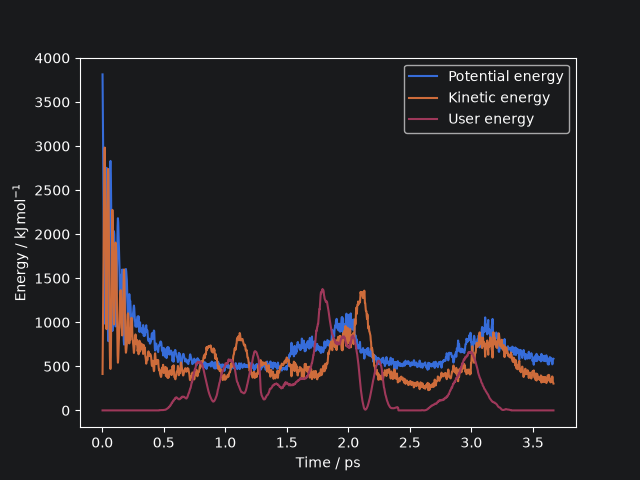

In [7]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(1)

data.plot(x="system.simulation.time", y="energy.potential", ax=axis, label="Potential energy")
data.plot(x="system.simulation.time", y="energy.kinetic", ax=axis, label="Kinetic energy")
data.plot(x="system.simulation.time", y="energy.user.total", ax=axis, label="User energy")

axis.legend()
axis.set_xlabel("Time / ps")
axis.set_ylabel(r"Energy / $\mathrm{kJ \, mol}^{-1}$")
plt.show()

Plotting these three energies tells us a lot about the pre-prepared iMD simulation. See if you can spot when:
* the user first grabbed the methane molecule
* the user pulled the methane through the nanotube

NanoVer delivers the potential energies of the molecular system and user interaction separately, giving the user the freedom to examine these quantities individually. For example, a user can explore the potential energy surface of the system efficiently by guiding the system into the configurations of interest, and recover the potential energy of the system _without_ the perturbing potential from the user forces.

## Plotting the methane trajectory

Now let's take a look at the trajectory of the methane through the simulation by plotting the position of the carbon atom of the methane as a function of time. We start by retrieving the position coordinates of the relevant atom (index 60) from the full list of coordinates, and then plot a 3D scatter plot of the positions. This plot is coloured using the Viridis colour palette according to the simulation time (positions at earlier times have darker colours, positions at later times have lighter colours).

In [8]:
C_METHANE_INDEX = 60

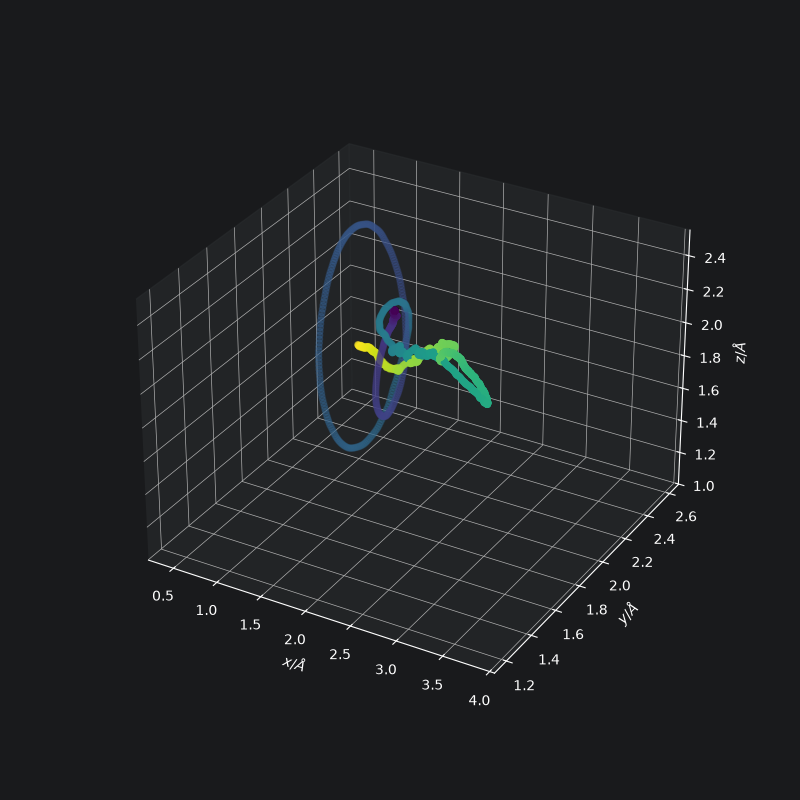

In [9]:
import numpy as np

# stack positions to a four-dimensional numpy array
positions = np.stack(data["particle.positions"])

# retrieve positions of methane carbon
c_methane_positions = positions[:, C_METHANE_INDEX, :]
count = len(c_methane_positions)

# plot trajectory in 3D with colour gradient
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
ax.scatter3D(c_methane_positions[:,0],
             c_methane_positions[:,1],
             c_methane_positions[:,2],
             c=np.linspace(0,1,count),
             cmap='viridis')
ax.set_xlabel(r"$x / \AA$")
ax.set_ylabel(r"$y / \AA$")
ax.set_zlabel(r"$z / \AA$")
plt.show()

You can interact with the plot above (provided you've run the first cell of the notebook containing `%matplotlib widget`). Have a play and see if you can spot when:
* the user pulls the methane in a circle
* the user pulls the methane through the nanotube for the first time
* the user pulls the methane through the nanotube for the second time

**Note**: You can replay the trajectory in VR (see optional section at the start of the notebook). This may be useful for interpreting the motion of the methane carbon during the simulation.

## Preparing the user forces

Because the iMD forces are usually applied to a tiny subset of atoms at a time, NanoVer stores them in a sparse format. We'll expand for ease of analysis:

In [10]:
import numpy as np
from nanover.imd.imd_force import expand_sparse_forces

COUNT = trajectory.first_frame.particle_count
EMPTY = np.zeros((COUNT, 3), dtype=np.float32)

SPARSE_INDEX = data["forces.user.index"]
SPARSE_FORCE = data["forces.user.sparse"]

data["user_forces"] = [expand_sparse_forces(COUNT, indices, forces) for indices, forces in zip(SPARSE_INDEX, SPARSE_FORCE)]
data["user_forces"]

0       [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
1       [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
2       [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
3       [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
4       [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
                              ...                        
1462    [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
1463    [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
1464    [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
1465    [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
1466    [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...
Name: user_forces, Length: 1467, dtype: object

## Analysing the user forces

Something of particular interest in iMD simulations is the interactions between the user(s) and the molecular system that bias the dynamics of the molecules. We can extract the user forces from the NanoVer recording (see above), and combine them with the forces from interactions within the molecular system to recover the total forces acting on the atoms. We'll do this for the carbon of the methane that the user interacted with during the simulation, and examine the magnitudes of the various forces acting on it.

**Note**: As with the potential energies of the molecular system and user interaction, NanoVer delivers the forces arising from interactions within the molecular system separately from the forces resulting from user interactions.

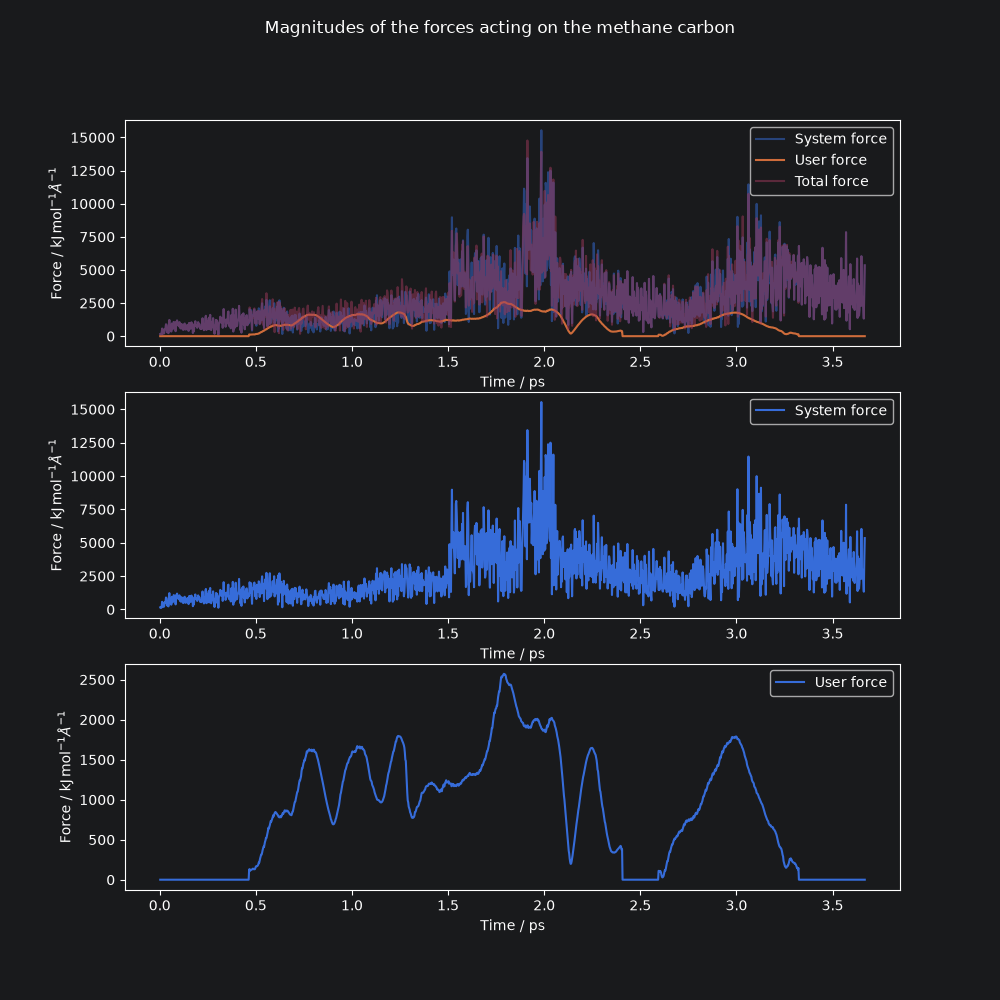

In [11]:
# convert system and user forces to four-dimensional numpy arrays
forces_system = np.stack(data["particle.forces.system"])
forces_user = np.stack(data["user_forces"])

# retrieve the system and user forces acting on the methane carbon
c_methane_forces_system = forces_system[:, C_METHANE_INDEX, :]
c_methane_forces_user = forces_user[:, C_METHANE_INDEX, :]

# recover the total force
c_methane_forces_total = c_methane_forces_system + c_methane_forces_user

# determine magnitudes of the forces
c_methane_forces_system_mag = np.zeros(c_methane_forces_system.shape[0])
c_methane_forces_user_mag = np.zeros(c_methane_forces_user.shape[0])
c_methane_forces_total_mag = np.zeros(c_methane_forces_total.shape[0])

for force in range(len(c_methane_forces_total)):
    c_methane_forces_system_mag[force] = np.linalg.norm(c_methane_forces_system[force])
    c_methane_forces_user_mag[force] = np.linalg.norm(c_methane_forces_user[force])
    c_methane_forces_total_mag[force] = np.linalg.norm(c_methane_forces_total[force])
    
# plot magnitudes of forces as functions of time
fig, (ax1, ax2, ax3) = plt.subplots(3)

fig.set_figheight(10)
fig.set_figwidth(10)
fig.suptitle('Magnitudes of the forces acting on the methane carbon')

T = data["system.simulation.time"]
ax1.plot(T, c_methane_forces_system_mag, label='System force', alpha=0.5)
ax1.plot(T, c_methane_forces_user_mag, label='User force')
ax1.plot(T, c_methane_forces_total_mag, label='Total force', alpha=0.5)
ax1.legend()
ax1.set_xlabel("Time / ps")
ax1.set_ylabel(r"Force / $\mathrm{kJ \, mol}^{-1} \AA^{-1}$")

ax2.plot(T, c_methane_forces_system_mag, label='System force')
ax2.legend()
ax2.set_xlabel("Time / ps")
ax2.set_ylabel(r"Force / $\mathrm{kJ \, mol}^{-1} \AA^{-1}$")

ax3.plot(T, c_methane_forces_user_mag, label='User force')
ax3.legend()
ax3.set_xlabel("Time / ps")
ax3.set_ylabel(r"Force / $\mathrm{kJ \, mol}^{-1} \AA^{-1}$")

plt.show()

See if you can tell from these plots:
* When the user first applies force to the system
* When the methane enters the nanotube for the first time
* When the methane enters the nanotube for the second time